最近在读 *TorchOptics: An open-source Python library for differentiable Fourier optics simulations* (arXiv:2411.18591)，本文复现其中 Figure 4 的 端到端 differentiable inverse-design 例子。

## 问题

给定一束输入 Gaussian beam，**直接优化**三块 phase-only SLM 的相位分布，使输出光场在目标平面匹配 *四束* Gaussian beam 的模式。整套系统里没有任何手工设计的相位或 Fourier 变换 mask —— 相位就是待优化参数。

## 系统布局

$$
\mathrm{Gaussian}_{\rm in}
\;\xrightarrow{M_1}\; P\;
\xrightarrow{M_2}\; P\;
\xrightarrow{M_3}\; P\;
\to \;\mathrm{four\;Gaussians}_{\rm out}
$$

三块 phase modulator $M_i = e^{i\phi_i(x,y)}$ 沿 $z$ 轴等距分布：

| 位置 | 距离 |
| --- | --- |
| $M_1$ | $z = 0.00\,\rm m$ |
| $M_2$ | $z = 0.20\,\rm m$ |
| $M_3$ | $z = 0.40\,\rm m$ |
| 目标面 | $z = 0.60\,\rm m$ |

每两块 SLM 之间的自由空间传播距离均为 $0.2\,\rm m$。

## 数值参数

| 参数 | 值 |
| --- | --- |
| 网格 | $250 \times 250$ |
| Pixel pitch | $10\,\mu\rm m$ |
| 波长 $\lambda$ | $700\,\rm nm$ |
| Gaussian waist $w_0$ | $150\,\mu\rm m$ |
| 目标束偏移 | $\pm 0.5\,\rm mm$（$\pm x$、$\pm y$ 四个象限） |
| 优化器 | Adam, $\mathrm{lr}=0.1$ |

## 优化变量

三块相位板的 phase profile $\phi_1,\phi_2,\phi_3$ 均从零相位开始 —— 初始系统等价于输入 Gaussian 自由传播 $0.6\,\rm m$。优化目标是最小化

$$
L = 1 - \eta, \qquad
\eta = \frac{\left|\int U_{\rm target}^*\, U_{\rm out}\, dA\right|^2}
            {\int |U_{\rm out}|^2 dA \cdot \int |U_{\rm target}|^2 dA},
$$

即 mode-overlap efficiency $\eta$。


In [ ]:
# pyright: reportAttributeAccessIssue=false

import numpy as onp
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt

# --- Numerical grid ---
wavelength = 700e-9  # 700 nm
nx, ny = 250, 250
dx = dy = 10e-6  # 10 um pixel pitch

# --- Source / target ---
w0 = 150e-6  # input Gaussian waist (= target waist)
target_offset = 0.5e-3  # distance of target beam centers from optical axis

# --- Optimizer ---
learning_rate = 0.1
n_iters = 100  # paper trains for 400 iterations

In [2]:
# These mirror wave_optics.{fft2c, ifft2c, make_grid, freq_grid, asm} but use
# autograd.numpy so the forward graph is differentiable through them.
# wave_optics.* is implemented in plain numpy, which autograd cannot trace.


def fft2c(U):
    """Centered 2D FFT: ifftshift -> fft2 -> fftshift."""
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(U)))


def ifft2c(A):
    """Centered 2D IFFT: ifftshift -> ifft2 -> fftshift."""
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(A)))


def make_grid(nx, ny, dx, dy=None):
    """Centered 2D spatial grid. Returns (X, Y, x, y)."""
    if dy is None:
        dy = dx
    x = (np.arange(nx) - nx // 2) * dx
    y = (np.arange(ny) - ny // 2) * dy
    X, Y = np.meshgrid(x, y)
    return X, Y, x, y


def freq_grid(nx, ny, dx, dy=None):
    """Centered 2D spatial-frequency grid. Returns (FX, FY, fx, fy)."""
    if dy is None:
        dy = dx
    fx = np.fft.fftshift(np.fft.fftfreq(nx, d=dx))
    fy = np.fft.fftshift(np.fft.fftfreq(ny, d=dy))
    FX, FY = np.meshgrid(fx, fy)
    return FX, FY, fx, fy


def asm(U0, z, wavelength, dx, dy=None):
    """Angular Spectrum Method (ASM), same coordinate system as the input."""
    if dy is None:
        dy = dx
    ny, nx = U0.shape
    k = 2 * np.pi / wavelength
    A = fft2c(U0)
    _, _, fx, fy = freq_grid(nx, ny, dx, dy)
    kx = 2 * np.pi * fx
    ky = 2 * np.pi * fy
    Kx, Ky = np.meshgrid(kx, ky)
    Kz = np.sqrt((k**2 - Kx**2 - Ky**2).astype(complex))
    return ifft2c(A * np.exp(1j * z * Kz))

In [3]:
def gaussian_beam(X, Y, w0, x0=0.0, y0=0.0):
    """A real-valued Gaussian beam profile on the centered (X, Y) grid."""
    R2 = (X - x0) ** 2 + (Y - y0) ** 2
    return np.exp(-R2 / w0**2)


def normalize_power(U, dx, dy=None):
    """Normalize so that the integrated intensity (∫|U|² dA) equals 1."""
    if dy is None:
        dy = dx
    power = np.sum(np.abs(U) ** 2) * dx * dy
    return U / np.sqrt(power)


def phase_modulate(U, phi):
    """Apply a phase-only mask phi to a complex field U."""
    return U * np.exp(1j * phi)


def propagate(U, z, wavelength, dx, dy=None):
    """Free-space propagation by z using ASM. Thin pass-through to `asm`."""
    return asm(U, z, wavelength, dx, dy)

In [4]:
X, Y, x, y = make_grid(nx, ny, dx, dy)

# Input: a single on-axis Gaussian beam.
U_in = normalize_power(gaussian_beam(X, Y, w0), dx)


def four_gaussian_target(X, Y, w0, offset):
    """Four Gaussian beams at the corners of a square of side 2*offset."""
    centers = [
        (-offset, -offset),
        (-offset, +offset),
        (+offset, -offset),
        (+offset, +offset),
    ]
    return sum(gaussian_beam(X, Y, w0, cx, cy) for cx, cy in centers)


U_target = normalize_power(four_gaussian_target(X, Y, w0, target_offset), dx)

# Phase profiles to optimize: start at zero phase.
phi1 = np.zeros((ny, nx))
phi2 = np.zeros((ny, nx))
phi3 = np.zeros((ny, nx))

In [5]:
def forward(U_in, phi1, phi2, phi3, wavelength, dx, dy=None):
    """Sequential M_1 -> P -> M_2 -> P -> M_3 -> P chain."""
    # z = 0
    U = phase_modulate(U_in, phi1)
    # z = 0 -> 0.2 m
    U = propagate(U, 0.2, wavelength, dx, dy)
    # z = 0.2 m
    U = phase_modulate(U, phi2)
    # z = 0.2 -> 0.4 m
    U = propagate(U, 0.2, wavelength, dx, dy)
    # z = 0.4 m
    U = phase_modulate(U, phi3)
    # z = 0.4 -> 0.6 m
    U = propagate(U, 0.2, wavelength, dx, dy)
    return U

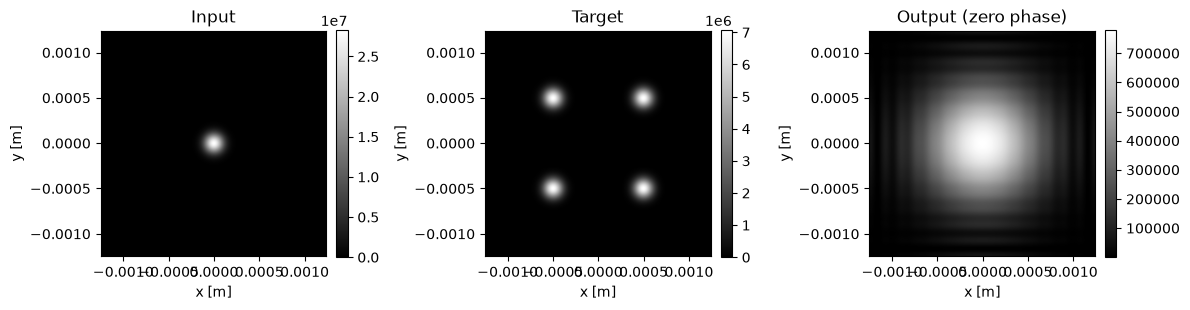

In [6]:
U_out_0 = forward(U_in, phi1, phi2, phi3, wavelength, dx)

extent = [onp.min(x), onp.max(x), onp.min(y), onp.max(y)]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, U, title in zip(
    axes,
    [U_in, U_target, U_out_0],
    ["Input", "Target", "Output (zero phase)"],
):
    im = ax.imshow(
        np.abs(U) ** 2,
        extent=extent,
        origin="lower",
        cmap="gray",
    )
    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [7]:
def mode_overlap(U_out, U_target):
    """Mode-overlap efficiency η ∈ [0, 1] between two normalized fields."""
    inner = np.sum(np.conj(U_target) * U_out) * dx * dy
    p_out = np.sum(np.abs(U_out) ** 2) * dx * dy
    p_tgt = np.sum(np.abs(U_target) ** 2) * dx * dy
    return np.abs(inner) ** 2 / (p_out * p_tgt)


def loss_fn(phi1, phi2, phi3):
    U_out = forward(U_in, phi1, phi2, phi3, wavelength, dx)
    return 1.0 - mode_overlap(U_out, U_target)


grad_phi1 = grad(loss_fn, 0)
grad_phi2 = grad(loss_fn, 1)
grad_phi3 = grad(loss_fn, 2)

loss = float(loss_fn(phi1, phi2, phi3))
g1 = grad_phi1(phi1, phi2, phi3)
g2 = grad_phi2(phi1, phi2, phi3)
g3 = grad_phi3(phi1, phi2, phi3)
print(f"initial loss       = {loss:.6f}")
print(f"initial overlap    = {1 - loss:.6f}")
print(f"mean |grad phi_i|  = " f"{[float(np.mean(np.abs(g))) for g in (g1, g2, g3)]}")

initial loss       = 0.957551
initial overlap    = 0.042449
mean |grad phi_i|  = [2.141470865442057e-07, 1.2745136380284992e-06, 2.2798724938105924e-06]


In [8]:
class Adam:
    """Plain Adam optimizer over a tensor of fixed shape.

    Keeps moments in plain numpy; the optimized variable itself is expected
    to be an autograd array (so its gradient is a Boxed array, which is
    accepted by the standard arithmetic ops below).
    """

    def __init__(self, shape, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = onp.zeros(shape)
        self.v = onp.zeros(shape)
        self.t = 0

    def update(self, x, g):
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * g
        self.v = self.beta2 * self.v + (1 - self.beta2) * g**2
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        return x - self.lr * m_hat / (onp.sqrt(v_hat) + self.eps)


adam1 = Adam(phi1.shape, lr=learning_rate)
adam2 = Adam(phi2.shape, lr=learning_rate)
adam3 = Adam(phi3.shape, lr=learning_rate)

iter=  0  loss=0.957551  overlap=0.042449
iter= 20  loss=0.164625  overlap=0.835375
iter= 40  loss=0.048679  overlap=0.951321
iter= 60  loss=0.022985  overlap=0.977015
iter= 80  loss=0.014983  overlap=0.985017
iter=100  loss=0.011377  overlap=0.988623
iter=120  loss=0.009375  overlap=0.990625
iter=140  loss=0.008058  overlap=0.991942
iter=160  loss=0.007062  overlap=0.992938
iter=180  loss=0.006294  overlap=0.993706
iter=200  loss=0.005726  overlap=0.994274
iter=220  loss=0.005294  overlap=0.994706
iter=240  loss=0.004939  overlap=0.995061
iter=260  loss=0.004639  overlap=0.995361
iter=280  loss=0.004401  overlap=0.995599
iter=300  loss=0.004215  overlap=0.995785
iter=320  loss=0.004057  overlap=0.995943
iter=340  loss=0.003928  overlap=0.996072
iter=360  loss=0.003802  overlap=0.996198
iter=380  loss=0.003685  overlap=0.996315
iter=399  loss=0.003597  overlap=0.996403


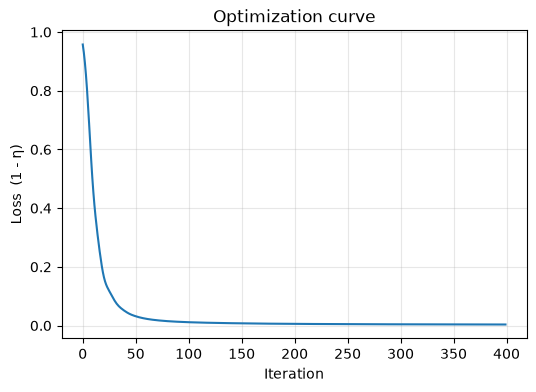

In [9]:
history = []

for it in range(n_iters):
    loss = loss_fn(phi1, phi2, phi3)

    g1 = grad_phi1(phi1, phi2, phi3)
    g2 = grad_phi2(phi1, phi2, phi3)
    g3 = grad_phi3(phi1, phi2, phi3)

    phi1 = adam1.update(phi1, g1)
    phi2 = adam2.update(phi2, g2)
    phi3 = adam3.update(phi3, g3)

    history.append(float(loss))
    if it % 20 == 0 or it == n_iters - 1:
        print(
            f"iter={it:3d}  "
            f"loss={float(loss):.6f}  "
            f"overlap={1 - float(loss):.6f}"
        )

plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Loss  (1 - η)")
plt.title("Optimization curve")
plt.grid(alpha=0.3)
plt.show()

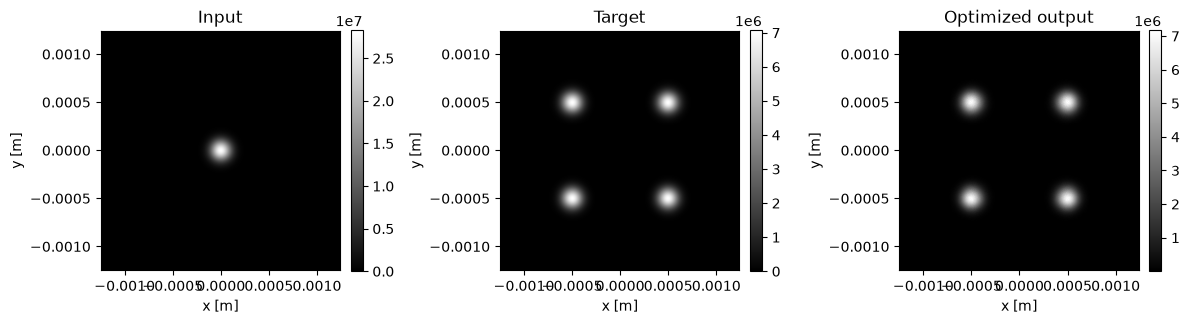

In [10]:
U_final = forward(U_in, phi1, phi2, phi3, wavelength, dx)

extent = [onp.min(x), onp.max(x), onp.min(y), onp.max(y)]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, U, title in zip(
    axes,
    [U_in, U_target, U_final],
    ["Input", "Target", "Optimized output"],
):
    im = ax.imshow(
        np.abs(U) ** 2,
        extent=extent,
        origin="lower",
        cmap="gray",
    )
    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

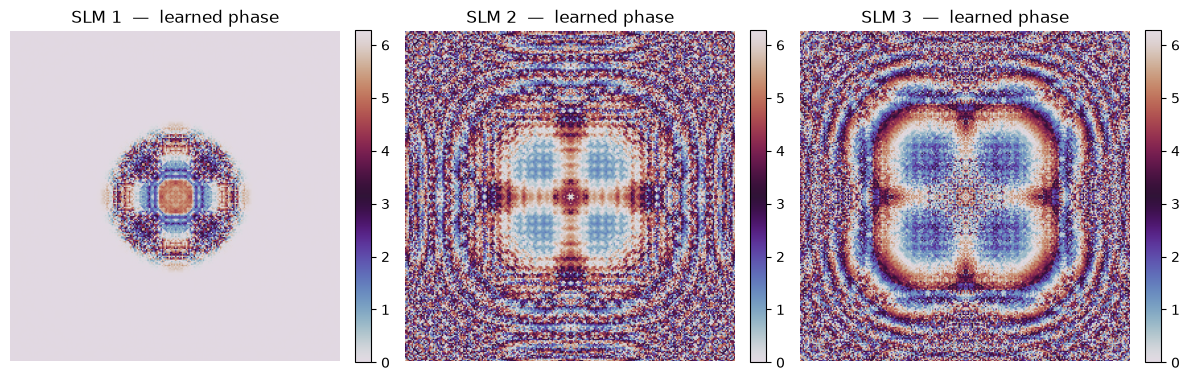

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, phi, i in zip(axes, [phi1, phi2, phi3], [1, 2, 3]):
    phase_wrapped = onp.mod(phi, 2 * onp.pi)
    im = ax.imshow(phase_wrapped, cmap="twilight", vmin=0, vmax=2 * onp.pi)
    ax.set_title(f"SLM {i}  —  learned phase")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()